In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.decomposition import PCA

In [2]:

df = pd.read_csv("music_cleaned.csv")

df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [3]:
#encode target var
label_encoder = LabelEncoder()
df["music_genre_encoded"] = label_encoder.fit_transform(df["music_genre"])

genre_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
genre_mapping

{'Alternative': np.int64(0),
 'Anime': np.int64(1),
 'Blues': np.int64(2),
 'Classical': np.int64(3),
 'Country': np.int64(4),
 'Electronic': np.int64(5),
 'Hip-Hop': np.int64(6),
 'Jazz': np.int64(7),
 'Rap': np.int64(8),
 'Rock': np.int64(9)}

feature engineering

In [4]:
df["energy_danceability"] = df["energy"] * df["danceability"]
df["tempo_energy"] = df["tempo"] * df["energy"]
df["loudness_energy"] = df["loudness"] * df["energy"]
df["acousticness_energy"] = df["acousticness"] * df["energy"]
df["tempo_log"] = np.log1p(df["tempo"])
df["duration_log"] = np.log1p(df["duration_ms"])
df["loudness_squared"] = df["loudness"] ** 2
df["tempo_bin"] = pd.cut(
    df["tempo"],
    bins=3,
    labels=["low_tempo", "medium_tempo", "high_tempo"]
)

df = pd.get_dummies(df, columns=["tempo_bin"], drop_first=True)

c:\Users\21667\anaconda3\envs\hw1\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Encode categorical variables

In [5]:
key_mapping = {
    "C": 0, "C#": 1, "D": 2, "D#": 3,
    "E": 4, "F": 5, "F#": 6, "G": 7,
    "G#": 8, "A": 9, "A#": 10, "B": 11
}

df["key"] = df["key"].map(key_mapping)
df = pd.get_dummies(df, columns=["mode", "obtained_date"], drop_first=True)


Feature hashing for text columns

In [6]:
hasher = FeatureHasher(n_features=10, input_type="string")

artist_input = df["artist_name"].astype(str).apply(lambda x: [x])
artist_hashed = hasher.transform(artist_input)

artist_df = pd.DataFrame(
    artist_hashed.toarray(),
    columns=[f"artist_hash_{i}" for i in range(10)]
)
track_input = df["track_name"].astype(str).apply(lambda x: [x])
track_hashed = hasher.transform(track_input)

track_df = pd.DataFrame(
    track_hashed.toarray(),
    columns=[f"track_hash_{i}" for i in range(10)]
)
df = pd.concat(
    [df.reset_index(drop=True), artist_df, track_df],
    axis=1
)

Build feature matrix

In [7]:
drop_cols = [
    "instance_id",
    "artist_name",
    "track_name",
    "music_genre",
    "music_genre_encoded"
]

X = df.drop(columns=drop_cols, errors="ignore")
y = df["music_genre_encoded"]
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))


Standardization& Export feature-engineered data

In [8]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

print(X.isna().sum().sort_values(ascending=False).head(20))

X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
feature_df = X_scaled_df.copy()
feature_df["music_genre"] = y.reset_index(drop=True)
feature_df = feature_df.astype("float32")
feature_df.to_csv("processed_musicData.csv", index=False)

popularity                0
acousticness              0
danceability              0
duration_ms               0
energy                    0
instrumentalness          0
key                       0
liveness                  0
loudness                  0
speechiness               0
tempo                     0
valence                   0
energy_danceability       0
tempo_energy              0
loudness_energy           0
acousticness_energy       0
tempo_log                 0
duration_log              0
loudness_squared          0
tempo_bin_medium_tempo    0
dtype: int64


Pca

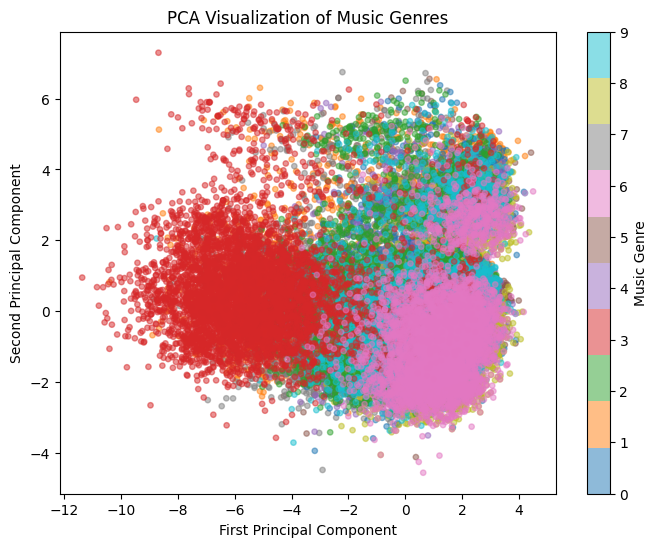

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["music_genre"] = y.reset_index(drop=True)

pca_df.to_csv("music_pca.csv", index=False)
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["music_genre"],
    cmap="tab10",
    alpha=0.5,
    s=15
)

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA Visualization of Music Genres")
plt.colorbar(scatter, label="Music Genre")
plt.show()

In [10]:
print("Explained variance by PC1:", pca.explained_variance_ratio_[0])
print("Explained variance by PC2:", pca.explained_variance_ratio_[1])
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance by PC1: 0.14120845544758165
Explained variance by PC2: 0.058375041670936094
Total explained variance: 0.19958349711851775


Interaction features were constructed, such as the product of energy and danceability, and tempo and energy, to capture the combined effects of multiple audio characteristics. These features allow the model to represent nonlinear relationships that are not reflected by individual variables alone.

Nonlinear transformations were also introduced, including logarithmic transformations of tempo and duration, and a squared transformation of loudness, to better model non-linear patterns in the data.

In addition, the continuous variable tempo was discretized into categorical bins, enabling the capture of threshold-based patterns. These bins were subsequently encoded using one-hot encoding.

Categorical variables were handled using appropriate encoding strategies. Musical key was mapped to numerical values, while low-cardinality variables were transformed using one-hot encoding. High-cardinality text features, such as artist and track names, were processed using feature hashing to reduce dimensionality while preserving informative signals.

In [11]:
feature_df = X_scaled_df.copy()
feature_df["music_genre"] = y.reset_index(drop=True)

feature_df.to_csv("music_feature_engineered.csv", index=False)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["music_genre"] = y.reset_index(drop=True)

pca_df.to_csv("music_pca.csv", index=False)